## Problem: Build a regression model to predict the price of a flight using the flights.csv dataset

In [50]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# Reading the dataset
df=pd.read_csv('E:\\Voyage-Analytics-Integrating-MLOps-in-Travel-Industry-\\app\\flight-price-service\\data\\raw\\flights.csv')

In [52]:
 # Dataset first view
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


### Dataset preparation

In [53]:
# Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  str    
 3   to          271888 non-null  str    
 4   flightType  271888 non-null  str    
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  str    
 9   date        271888 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 35.0 MB


In [54]:
# No null values
df.isnull().sum()

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

In [55]:
# Checking the data types
df.dtypes

travelCode      int64
userCode        int64
from              str
to                str
flightType        str
price         float64
time          float64
distance      float64
agency            str
date              str
dtype: object

In [56]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

In [57]:
# Checking if there are any outliers
df.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


In [58]:
# Checking skewness
df['price'].skew()


np.float64(0.3135775686612521)

A skewness of ~0.31 indicates near symmetry, so no transformation is required.

In [59]:
# Checking Data consistency
df.nunique()

travelCode    135944
userCode        1335
from               9
to                 9
flightType         3
price            490
time              33
distance          35
agency             3
date             999
dtype: int64

In [60]:
# Type casting
df['price']=df['price'].astype(int)
df['date']=df['date'].astype('datetime64[ns]')

### Feature engineering

In [61]:
# Droping the columns
df.drop(columns=['travelCode', 'userCode'], inplace=True)

In [62]:
# Extract the day, month, and year from the date column
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Drop original
df.drop('date', axis=1, inplace=True)

In [63]:
# Getting categorical variable
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['from', 'to', 'flightType', 'agency'], dtype='str')


C:\Users\Bharat Shewale\AppData\Local\Temp\ipykernel_9440\2425624498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [64]:
df.head()

,from,to,flightType,price,time,distance,agency,day,month,year
0,Recife (PE),Florianopolis (SC),firstClass,1434,1.76,676.53,FlyingDrops,26,9,2019
1,Florianopolis (SC),Recife (PE),firstClass,1292,1.76,676.53,FlyingDrops,30,9,2019
2,Brasilia (DF),Florianopolis (SC),firstClass,1487,1.66,637.56,CloudFy,3,10,2019
3,Florianopolis (SC),Brasilia (DF),firstClass,1127,1.66,637.56,CloudFy,4,10,2019
4,Aracaju (SE),Salvador (BH),firstClass,1684,2.16,830.86,CloudFy,10,10,2019


In [65]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = encoder.fit_transform(df[['from', 'to', 'agency']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['from', 'to', 'agency']),
    index=df.index
)

df = pd.concat(
    [df.drop(columns=['from', 'to', 'agency']), encoded_df],
    axis=1
)

In [66]:
model_path="E:\\Voyage-Analytics-Integrating-MLOps-in-Travel-Industry-\\app\\flight-price-service\\models\\regression"

import joblib
joblib.dump(encoder, f"{model_path}\\from_encoder.pkl")


['E:\\Voyage-Analytics-Integrating-MLOps-in-Travel-Industry-\\app\\flight-price-service\\models\\regression\\from_encoder.pkl']

In [67]:
# Ordinal Encoding flightType
FLIGHT_TYPE_MAP = {
    "economy": 0,
    "business": 1,
    "firstClass": 2
}

df['flightType'] = df['flightType'].map(FLIGHT_TYPE_MAP)
joblib.dump(FLIGHT_TYPE_MAP, f"{model_path}\\flight_type_map.pkl")


['E:\\Voyage-Analytics-Integrating-MLOps-in-Travel-Industry-\\app\\flight-price-service\\models\\regression\\flight_type_map.pkl']

In [68]:
df.tail()

,flightType,price,time,distance,day,month,year,from_Aracaju (SE),from_Brasilia (DF),from_Campo Grande (MS),...,to_Campo Grande (MS),to_Florianopolis (SC),to_Natal (RN),to_Recife (PE),to_Rio de Janeiro (RJ),to_Salvador (BH),to_Sao Paulo (SP),agency_CloudFy,agency_FlyingDrops,agency_Rainbow
271883,2.0,1446,1.49,573.81,12,7,2020,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
271884,NaN,726,1.84,709.37,16,7,2020,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
271885,NaN,873,1.84,709.37,20,7,2020,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
271886,NaN,313,1.21,466.30,23,7,2020,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
271887,NaN,533,1.21,466.30,26,7,2020,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


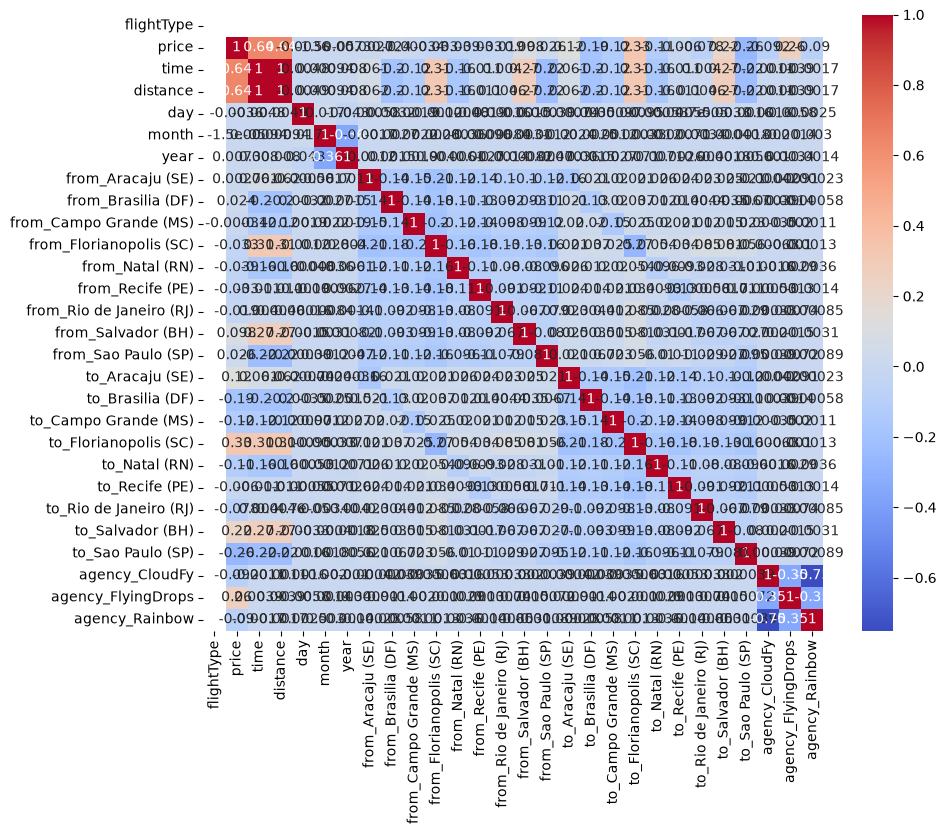

In [69]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [70]:
# Splitting the data
from sklearn.model_selection import train_test_split
X = df.drop('price', axis=1)
y = df['price']

In [71]:
# Saving the feature columns
FEATURE_COLUMNS = X.columns.tolist()
joblib.dump(FEATURE_COLUMNS, f"{model_path}\\feature_columns.pkl")

['E:\\Voyage-Analytics-Integrating-MLOps-in-Travel-Industry-\\app\\flight-price-service\\models\\regression\\feature_columns.pkl']

### Model selections

In [72]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model 1 : Decision tree regressor


In [73]:
# Importing Decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Fitting
dt = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=10,
    min_samples_leaf=50,
    min_samples_split=100,
    max_features=5,
    random_state=42
)
dt.fit(X_train, y_train)

# Prediction
y_pred = dt.predict(X_test)
print(y_pred)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MSE:', mse)
print('R2:', r2)

[ 393.35261708  981.52202482 1213.94827586 ...  961.          968.175
 1616.        ]
MSE: 23397.987628518942
R2: 0.8224303448759797


Model 2 : Random Forest Regressor

In [74]:
# Importing model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Fitting
rf = RandomForestRegressor(n_estimators=505,
    max_depth=13,
    min_samples_leaf=57,
    min_samples_split=134,
    max_features=5,
    bootstrap=True,
    n_jobs=-1,
    random_state=42)
rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)
print(y_pred)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MSE:', mse)
print('R2:', r2)

[ 410.11125378 1116.48984106 1022.58004983 ...  951.77572759  828.10188927
 1615.37347358]
MSE: 11265.206556682731
R2: 0.9145072270773901


Model 3 : XGBoost Regressor

In [76]:
# Importing model
from xgboost import XGBRegressor

# Fitting model
xgb = XGBRegressor(n_estimators= 500,
                   learning_rate= 0.08,
                   max_depth= 5,
                   reg_alpha= 0.0007787658410143283,
                   reg_lambda= 3.47,
                   subsample= 0.88)
xgb.fit(X_train, y_train)

# Prediction
y_pred = xgb.predict(X_test)
print(y_pred)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MSE:', mse)
print('R2:', r2)

[ 407.02283 1129.7981  1024.2454  ...  951.88574  819.9899  1616.4368 ]
MSE: 10991.3466796875
R2: 0.9165855646133423


In [77]:
# saving XGBoost regressor model
import joblib
joblib.dump(xgb, f"{model_path}\\xgb_regressor.pkl")


['E:\\Voyage-Analytics-Integrating-MLOps-in-Travel-Industry-\\app\\flight-price-service\\models\\regression\\xgb_regressor.pkl']

## Goal: Develop a REST API using Flask to serve the flight price prediction model, enabling real-time price predictions.